# PrismBench API

**PrismBench** is a benchmark and preference-aware routing framework for data science agents. This notebook tours the public Python API.

Run order:

1. Load the master scorecard summary (one row per *(agent, task)*).
2. Build the per-agent routing matrix over the seven dimensions.
3. Normalize via min-max so all dimensions live on `[0, 1]`.
4. Score with three MCDM methods: WSM, TOPSIS, PROMETHEE-II.
5. Compare method agreement with Kendall tau.
6. Extract a 2D Pareto frontier.
7. Run a sensitivity sweep on one weight axis.

All functions are imported from `src.router`. Source:  [`src/router.py`](src/router.py).


## 1. Load the scorecard

`load_summary()` reads `results/master_scorecard_summary.csv`. That file is produced by `python -m src.scorecard` after a benchmark run; it has one row per *(agent, task)* with the mean across runs.


In [1]:
import pandas as pd
from src import router

summary = router.load_summary()
print(f'rows: {len(summary)}')
print(f'agents: {sorted(summary["agent"].unique())}')
print(f'tasks:  {sorted(summary["task_id"].unique())}')
summary.head()


rows: 68
agents: ['autogen', 'autogluon', 'chatgpt_ada', 'claude_api_raw', 'claude_code', 'langgraph', 'pandasai', 'pycaret', 'smolagents']
tasks:  ['AR-PRED-01', 'AR-PRED-STRICT-01', 'AR-ROBU-01', 'HD-DESC-01', 'HD-PRED-01', 'HD-PRED-01_diag10', 'HD-PRED-STRICT-01', 'HD-ROBU-01', 'TAXI-PRED-01', 'TAXI-PRED-STRICT-01']


,agent,task_id,D1_f1,D1_accuracy,D1_auc_roc,D1_rmse,D1_r2,D2_pylint,D2_llm_judge,D2_combined,D3_auto_score,D3_llm_judge,D3_combined,D3_shap,D4_time_sec,D5_cost_usd,D5_tokens,D5_carbon_kg,D6_cv,D6_std
0,autogen,AR-PRED-01,0.4649,0.5850,NaN,NaN,NaN,3.3333,5.2500,5.1250,2.0,2.0000,2.5000,0.0,1530.3270,0.1632,54917.0,0.0319,NaN,NaN
1,autogen,AR-PRED-STRICT-01,0.8830,0.8999,0.9380,NaN,NaN,7.1333,NaN,NaN,0.0,NaN,NaN,0.0,45.6903,0.0000,0.0,0.0001,0.0256,0.0226
2,autogen,AR-ROBU-01,NaN,NaN,NaN,NaN,NaN,8.1000,NaN,NaN,3.0,NaN,NaN,0.0,82.6550,0.1462,45276.0,0.0229,NaN,NaN
3,autogen,HD-PRED-01,0.8899,0.8900,0.9433,NaN,NaN,4.0667,5.6667,4.8667,3.0,3.1667,3.0833,0.0,49.0630,0.0968,32540.0,0.0164,0.0115,0.0102
4,autogen,HD-PRED-STRICT-01,0.8745,0.8743,0.9443,NaN,NaN,6.6667,NaN,NaN,3.0,NaN,NaN,0.0,20.0977,0.0545,18323.0,0.0092,0.0109,0.0095


## 2. Build the routing matrix

`build_routing_matrix(summary, tasks=None)` aggregates the per-task rows into one row per agent with the seven routing dimensions populated. By default it filters to the three main benchmark tasks (`HD-PRED-01`, `TAXI-PRED-01`, `AR-PRED-01`).

Dimensions (with direction):

- `primary`     accuracy, higher is better
- `D2_combined` code quality (pylint + LLM judge), higher is better
- `D3_combined` explainability, higher is better
- `D4_time_sec` wall-clock seconds, lower is better
- `D5_cost_usd` API USD, lower is better
- `D5_carbon_kg` kg CO2, lower is better
- `D6_cv` coefficient of variation across runs, lower is better


In [2]:
matrix = router.build_routing_matrix(summary)
matrix.round(4)


,D2_combined,D3_combined,D4_time_sec,D5_cost_usd,D5_carbon_kg,D6_cv,primary,n_tasks_successful,n_tasks_total
agent,,,,,,,,,
autogen,5.6972,2.8889,547.6698,0.1255,0.0225,0.0058,0.2145,3,3
autogluon,NaN,NaN,124.0957,0.0000,0.0004,0.0076,0.8902,3,3
chatgpt_ada,4.5056,3.3750,205.9918,0.0221,0.0022,0.0106,0.3878,2,3
claude_api_raw,5.6833,3.0556,24.7070,0.0367,0.0013,0.1017,0.6458,3,3
claude_code,6.7667,4.3611,52.5032,0.0036,0.0004,0.0297,0.5138,3,3
langgraph,5.0528,3.1528,23.9358,0.0317,0.0012,0.0120,0.6812,3,3
pandasai,NaN,NaN,48.5040,0.0622,0.0065,NaN,NaN,0,3
pycaret,NaN,NaN,23.8171,0.0000,0.0001,0.0000,0.0000,3,3
smolagents,3.2556,3.4444,53.2656,0.1121,0.0177,NaN,NaN,0,3


## 3. Normalize

`normalize(matrix)` applies min-max normalization per dimension and flips the sign on lower-is-better dimensions, so every column ends up on `[0, 1]` with `1` = best.


In [3]:
normalized = router.normalize(matrix)
normalized.round(3)


,D2_combined,D3_combined,D4_time_sec,D5_cost_usd,D5_carbon_kg,D6_cv,primary,n_tasks_successful,n_tasks_total
agent,,,,,,,,,
autogen,0.695,0.000,0.000,0.000,0.000,0.943,0.241,3,3
autogluon,0.000,0.000,0.809,1.000,0.985,0.925,1.000,3,3
chatgpt_ada,0.356,0.330,0.652,0.824,0.906,0.896,0.436,2,3
claude_api_raw,0.691,0.113,0.998,0.708,0.945,0.000,0.725,3,3
claude_code,1.000,1.000,0.945,0.971,0.984,0.708,0.577,3,3
langgraph,0.512,0.179,1.000,0.747,0.949,0.882,0.765,3,3
pandasai,0.000,0.000,0.953,0.504,0.715,0.000,0.000,0,3
pycaret,0.000,0.000,1.000,1.000,1.000,1.000,0.000,3,3
smolagents,0.000,0.377,0.944,0.107,0.214,0.000,0.000,0,3


## 4. Score with three MCDM methods

PrismBench implements three Multi-Criteria Decision Making methods:

- **WSM** (Weighted Sum Model)  additive baseline.
- **TOPSIS**  distance from ideal and anti-ideal points after weighted   normalization.
- **PROMETHEE-II**  pairwise net flow with linear preference function.

We use the `balanced` preset weight (uniform `1/7` on every dimension). Six other presets ship in `router.PRESETS` (`accuracy`, `frugal`, `quality`, `green`, `production`).


In [4]:
weights = router.PRESETS['balanced']
weights


{'D1': 0.14285714285714285,
 'D2': 0.14285714285714285,
 'D3': 0.14285714285714285,
 'D4_speed': 0.14285714285714285,
 'D5_cost': 0.14285714285714285,
 'D5_carbon': 0.14285714285714285,
 'D6_robust': 0.14285714285714285}

In [5]:
wsm_score       = router.wsm(normalized, weights)
topsis_score    = router.topsis(normalized, weights)
promethee_score = router.promethee(normalized, weights)

ranks = pd.DataFrame({
    'WSM':       wsm_score,
    'TOPSIS':    topsis_score,
    'PROMETHEE': promethee_score,
}).round(3)
ranks.sort_values('WSM', ascending=False)


,WSM,TOPSIS,PROMETHEE
agent,,,
claude_code,0.884,0.821,0.383
langgraph,0.719,0.665,0.198
autogluon,0.674,0.597,0.147
chatgpt_ada,0.629,0.604,0.096
claude_api_raw,0.597,0.563,0.061
pycaret,0.571,0.536,0.032
pandasai,0.310,0.383,-0.262
autogen,0.269,0.356,-0.309
smolagents,0.235,0.323,-0.347


## 5. Method agreement: Kendall tau

`kendall_tau_table` computes pairwise Kendall tau across the three rankings. Theoretical Proposition 1 in the report shows WSM and PROMETHEE-II are equivalent under min-max normalized scores with the linear preference function -- expect `tau = 1.0` for that pair.


In [6]:
rankings = {
    'wsm':       wsm_score,
    'topsis':    topsis_score,
    'promethee': promethee_score,
}
router.kendall_tau_table(rankings).round(3)


,wsm,topsis,promethee
wsm,1.000,0.944,1.000
topsis,0.944,1.000,0.944
promethee,1.000,0.944,1.000


## 6. Pareto frontier in 2D

`pareto_2d` returns the non-dominated agents under a chosen 2D projection. We illustrate the accuracy-vs-cost projection: AutoGluon should be the unique non-dominated agent (highest D1 at zero per-run API cost).


In [7]:
pareto = router.pareto_2d(
    matrix,
    x_col='D5_cost_usd',
    y_col='primary',
    x_lower_better=True,
    y_lower_better=False,
)
print('Pareto-optimal in (cost, accuracy):', pareto)


Pareto-optimal in (cost, accuracy): agent
autogen           False
autogluon          True
chatgpt_ada       False
claude_api_raw    False
claude_code       False
langgraph         False
pandasai          False
pycaret           False
smolagents        False
dtype: bool


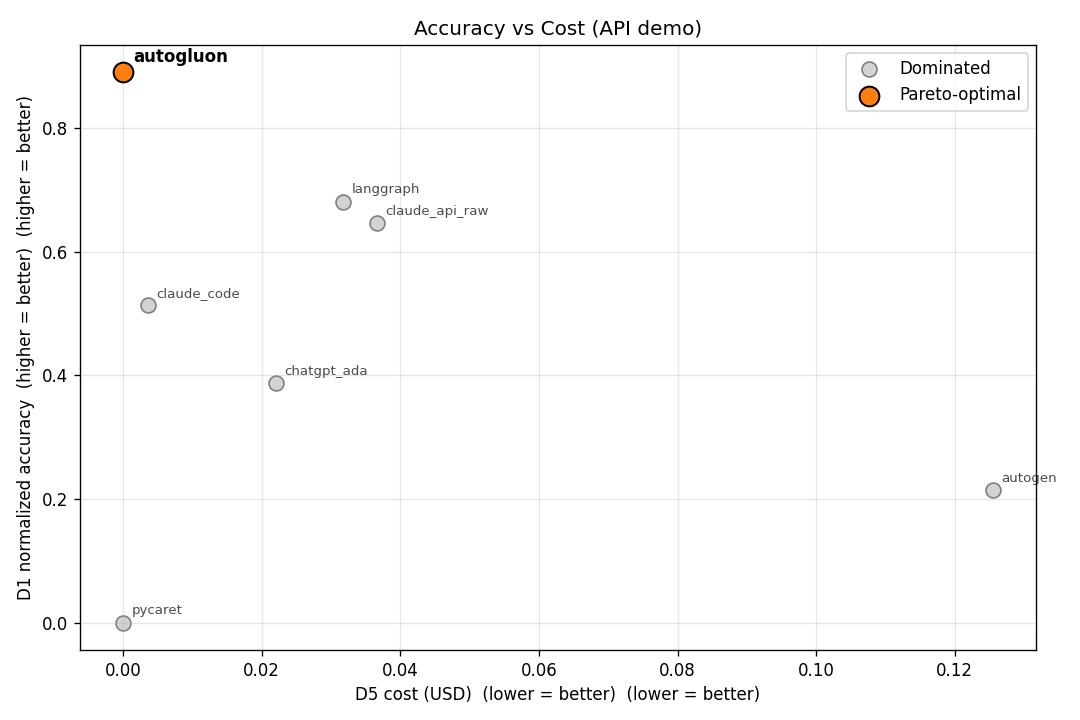

In [8]:
from pathlib import Path
fig_path = Path('figures/api_pareto_demo.png')
router.plot_pareto_2d(
    matrix,
    x_col='D5_cost_usd',
    y_col='primary',
    x_label='D5 cost (USD)  (lower = better)',
    y_label='D1 normalized accuracy  (higher = better)',
    title='Accuracy vs Cost (API demo)',
    output_path=str(fig_path),
    x_lower_better=True,
    y_lower_better=False,
)
from IPython.display import Image
Image(str(fig_path))


## 7. Sensitivity sweep

`sensitivity_sweep(target_dim, n_steps=21, method='wsm')` varies the target dimension's weight from `0` to `1` while distributing the complement uniformly across the remaining six dimensions. The point at which the top-ranked agent flips is a *breakpoint*; a routing recommendation is robust if no breakpoint sits near the user's nominal weight.


In [9]:
sweep = router.sensitivity_sweep('D1', n_steps=21, method='wsm')
sweep.head()


,target_weight,agent,score,rank
0,0.0,claude_code,0.934765,1
1,0.0,langgraph,0.711640,2
2,0.0,pycaret,0.666667,3
3,0.0,chatgpt_ada,0.660751,4
4,0.0,autogluon,0.619835,5


In [10]:
breakpoints = router.find_top1_breakpoints(sweep)
breakpoints


[(0.45, 'claude_code', 'autogluon')]

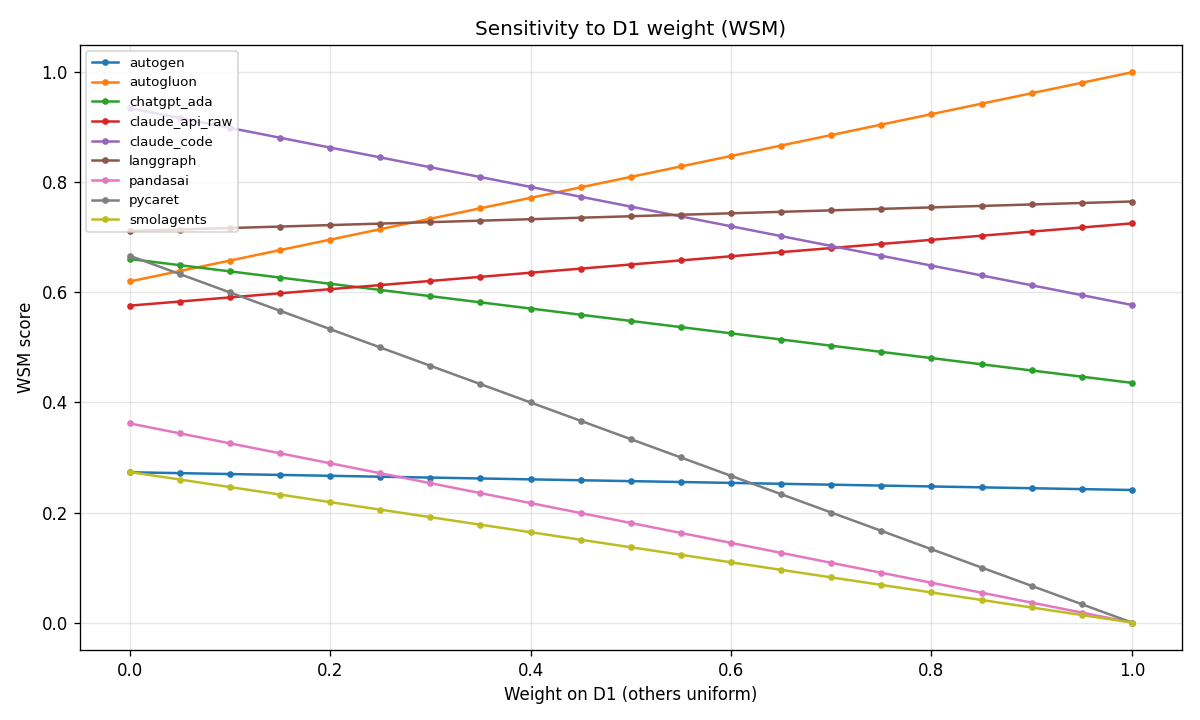

In [11]:
fig_path = Path('figures/api_sensitivity_demo.png')
router.plot_sensitivity(sweep, target_dim='D1', output_path=str(fig_path), method='wsm')
Image(str(fig_path))


## 8. One-shot: `recommend(weights)`

If you only need the headline answer, `recommend` runs all three methods and returns the top agent under each:


In [12]:
for preset_name in ['balanced', 'accuracy', 'frugal', 'green']:
    rec = router.recommend(router.PRESETS[preset_name])
    tops = {m: list(s.index)[0] for m, s in rec['rankings'].items()}
    print(f'{preset_name:>10}: {tops}')


  balanced: {'wsm': 'claude_code', 'topsis': 'claude_code', 'promethee': 'claude_code'}
  accuracy: {'wsm': 'autogluon', 'topsis': 'autogluon', 'promethee': 'autogluon'}
    frugal: {'wsm': 'claude_code', 'topsis': 'claude_code', 'promethee': 'claude_code'}
     green: {'wsm': 'autogluon', 'topsis': 'autogluon', 'promethee': 'autogluon'}


## Where to go next

- [`prismbench.example.ipynb`](prismbench.example.ipynb)  end-to-end run of one agent on one task.
- [`report.pdf`](report.pdf)  full empirical study with statistical validation, multi-protocol analysis, and Theoretical Proposition 1.
- [`results/master_scorecard.csv`](results/master_scorecard.csv)  the raw cell-level data backing every figure and number in the report.
- [`src/router.py`](src/router.py)  source for everything imported here.
